In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from geodesic_toolbox import *
from functools import partial
from sklearn.datasets import make_swiss_roll
from utils import *

# 2D Dummy data

In [2]:
device = "cpu"
def get_bounds(embeddings: torch.Tensor, margin: float = 0.0) -> torch.Tensor:
    """
    Compute the bounds of the embeddings.

    Parameters:
    ----------
    embeddings : torch.Tensor (n_points, 2)
        The embeddings of the points.
    margin : float
        Margin scaling factor to add to the bounds. (default is 0)
        This is useful to avoid points being too close to the edges of the plot.

    Returns:
    -------
    torch.Tensor (4,)
        [min_x, max_x, min_y, max_y], the bounds of the embeddings.
    """
    min_x, max_x = embeddings[:, 0].min(), embeddings[:, 0].max()
    min_y, max_y = embeddings[:, 1].min(), embeddings[:, 1].max()
    # Add margin to the bounds
    min_x -= margin * (max_x - min_x)
    max_x += margin * (max_x - min_x)
    min_y -= margin * (max_y - min_y)
    max_y += margin * (max_y - min_y)
    # Ensure the bounds are in the correct order
    min_x, max_x = min(min_x, max_x), max(min_x, max_x)
    min_y, max_y = min(min_y, max_y), max(min_y, max_y)
    # Create a tensor with the bounds
    bounds = [min_x, max_x, min_y, max_y]
    bounds = torch.tensor(bounds)
    return bounds

def get_spiral(n_pts: int, freq: float, sigma: float = 0.1, t_max: float = 4 * np.pi):
    # Sample uniformly in arc length on the noiseless spiral, then add noise.
    t_dense = np.linspace(0.0, t_max, max(5000, 10 * n_pts))
    speed = np.sqrt(1.0 + (freq * t_dense) ** 2)
    ds = 0.5 * (speed[1:] + speed[:-1]) * np.diff(t_dense)
    s_dense = np.concatenate(([0.0], np.cumsum(ds)))
    s_uniform = np.linspace(0.0, s_dense[-1], n_pts)
    t = np.interp(s_uniform, s_dense, t_dense)

    x = t * np.cos(freq * t) + np.random.normal(0, sigma, n_pts)
    y = t * np.sin(freq * t) + np.random.normal(0, sigma, n_pts)
    X = np.stack([x, y], axis=1)

    # Normalize the data
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    s = s_uniform / s_uniform[-1]
    X = torch.from_numpy(X).double().to(device)
    s = torch.from_numpy(s).double().to(device)
    return X, s


def get_x_plt(resolution: int, bounds: tuple = (-2, 2, -2, 2)):
    x = np.linspace(bounds[0], bounds[1], resolution)
    y = np.linspace(bounds[2], bounds[3], resolution)
    xx, yy = np.meshgrid(x, y)
    X_plt = np.stack([xx.flatten(), yy.flatten()], axis=1)
    return torch.from_numpy(X_plt).float().to(device)


def spiral_omega(z: torch.Tensor, freq: float) -> torch.Tensor:
    """
    Compute the omega vector field for a spiral.

    Parameters:
    ----------
    z : torch.Tensor (n_points, 2)
        The input points in 2D space.
    freq : float
        The frequency of the spiral.

    Returns:
    -------
    torch.Tensor (n_points, 2)
        The omega vector field at the input points.
    """
    x = z[:, 0]
    y = z[:, 1]
    t = torch.sqrt(x**2 + y**2)
    omega_x = -freq * y / (t + 1e-8)  # Avoid division by zero
    omega_y = freq * x / (t + 1e-8)   # Avoid division by zero
    omega = torch.stack([omega_x, omega_y], dim=1)
    return omega / torch.norm(omega, dim=1, keepdim=True)  # Normalize the vector field




In [3]:
class CometricSpiral(torch.nn.Module):
    def __init__(self, cometric:CoMetric, freq: float = 1.0):
        super().__init__()
        self.cometric = cometric
        self.freq = freq

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        omega = spiral_omega(z, freq=self.freq)
        norm_omega = self.cometric.cometric(z, omega)
        omega = omega / (norm_omega.unsqueeze(1) + 1e-8)  # Avoid division by zero
        return omega

In [4]:
X, t = get_spiral(3000, freq=1.0, sigma=0.5)
base_cometric = CentroidsCometric(X, IdentityCoMetric()(X), K=-1, temperature_scale=0.5)

omega_spiral_ = partial(spiral_omega, freq=1.0)
omega_X = omega_spiral_(X)
bounds = get_bounds(X, margin=0.2)


Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 128.14batch/s]


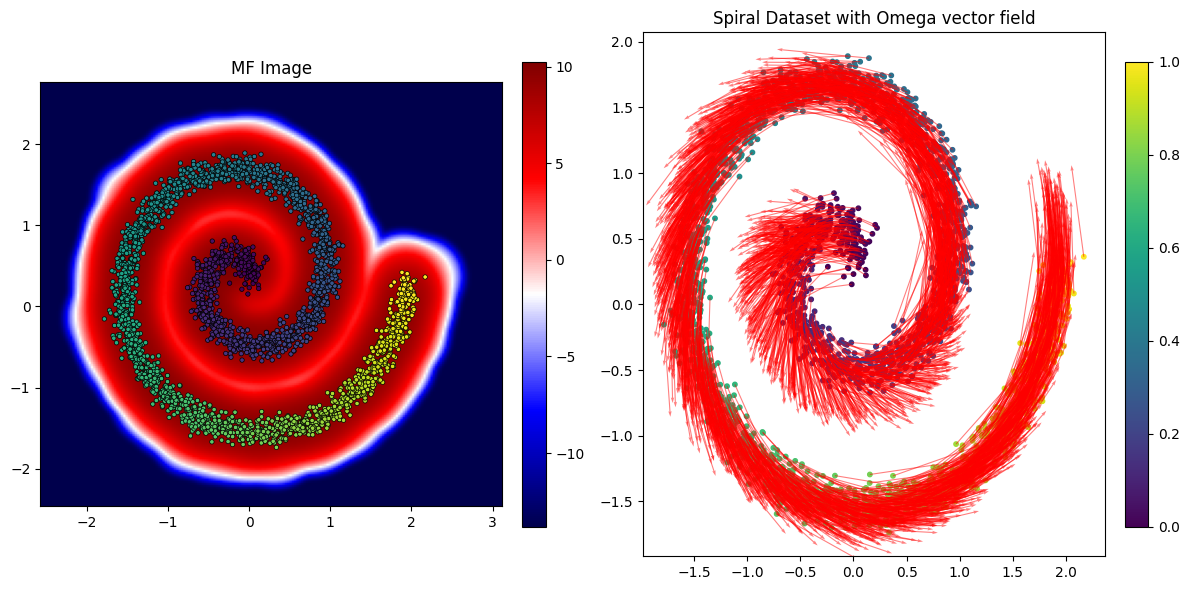

In [5]:
mf = get_mf_image(base_cometric, X, bounds)


fig, axes = plt.subplots(1,2, figsize=(12, 6))
im = axes[0].imshow(mf.cpu().numpy(), cmap="seismic", origin="lower", extent=bounds)
t_cbar = axes[0].scatter(
    X[:, 0].cpu(), X[:, 1].cpu(), c=t.cpu(), cmap="viridis", s=10, edgecolor="k", linewidth=0.5
)
axes[0].set_title("MF Image")
axes[1].scatter(X[:, 0], X[:, 1], c=t, cmap="viridis", s=10)
axes[1].quiver(X[::, 0], X[::, 1], omega_X[::, 0], omega_X[::, 1], color='red', alpha=0.5, scale=5, angles='xy')
axes[1].set_title("Spiral Dataset with Omega vector field")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(t_cbar, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.tight_layout()
plt.show()

In [6]:
omega_true = CometricSpiral(base_cometric, freq=1.0)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=0.5
)

In [7]:
solver_r = SolverGraph(cometric=base_cometric,
                       data=X,
                       n_neighbors=8,
                       )
solver_f = SolverGraphFinsler(finsler_metric=randers_metric,
                            data=X,
                            n_neighbors=8,
                            )

Initialize Graph: 100%|██████████| 47/47 [00:26<00:00,  1.80batch/s]


Computing predecessors...
Done.


Initialize Graph: 100%|██████████| 47/47 [00:50<00:00,  1.07s/batch]


Computing predecessors...
Done.


In [8]:
alpha_true = solver_r.W
edges = solver_f.W.nonzero(as_tuple=False)
dx = X[edges[:, 1]] - X[edges[:, 0]]
beta_true = torch.einsum('bi,bi->b', omega_true(X[edges[:, 0]]), dx)
beta_true = randers_metric.beta * beta_true

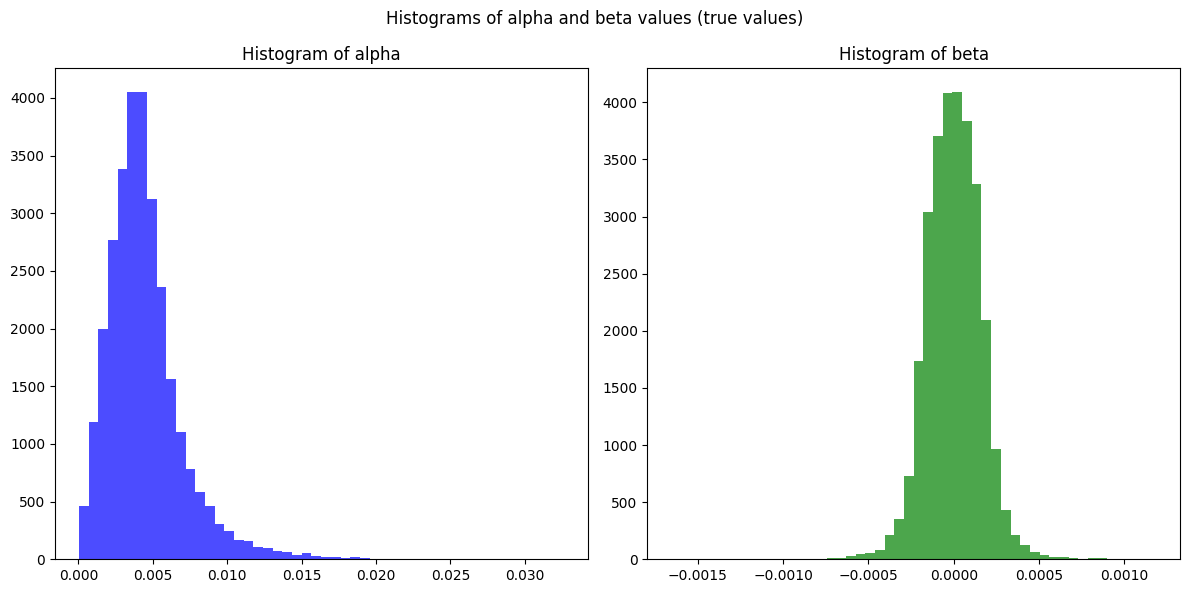

In [9]:
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].hist(alpha_true[alpha_true>0].cpu().numpy(), bins=50, color='blue', alpha=0.7)
axes[0].set_title("Histogram of alpha")
axes[1].hist(beta_true.cpu().numpy(), bins=50, color='green', alpha=0.7)
axes[1].set_title("Histogram of beta")
plt.suptitle("Histograms of alpha and beta values (true values)")
plt.tight_layout()

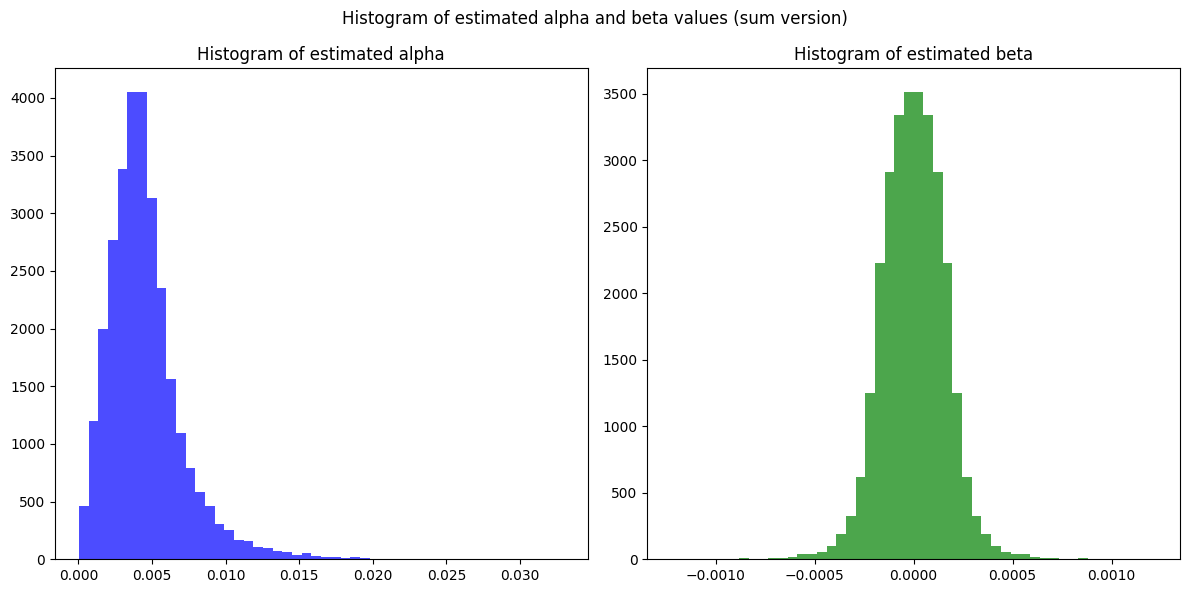

In [10]:
W = solver_f.W
valid_edges_plt = W > 0
valid_edges = valid_edges_plt.nonzero(as_tuple=False)

alpha_hat_sum = (W + W.T) / 2
beta_hat_sum = (W - W.T) / 2

fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].hist(alpha_hat_sum[valid_edges_plt].cpu().numpy(), bins=50, color='blue', alpha=0.7)
axes[0].set_title("Histogram of estimated alpha")
axes[1].hist(beta_hat_sum[valid_edges_plt].cpu().numpy(), bins=50, color='green', alpha=0.7)
axes[1].set_title("Histogram of estimated beta")
plt.suptitle("Histogram of estimated alpha and beta values (sum version)")
plt.tight_layout()

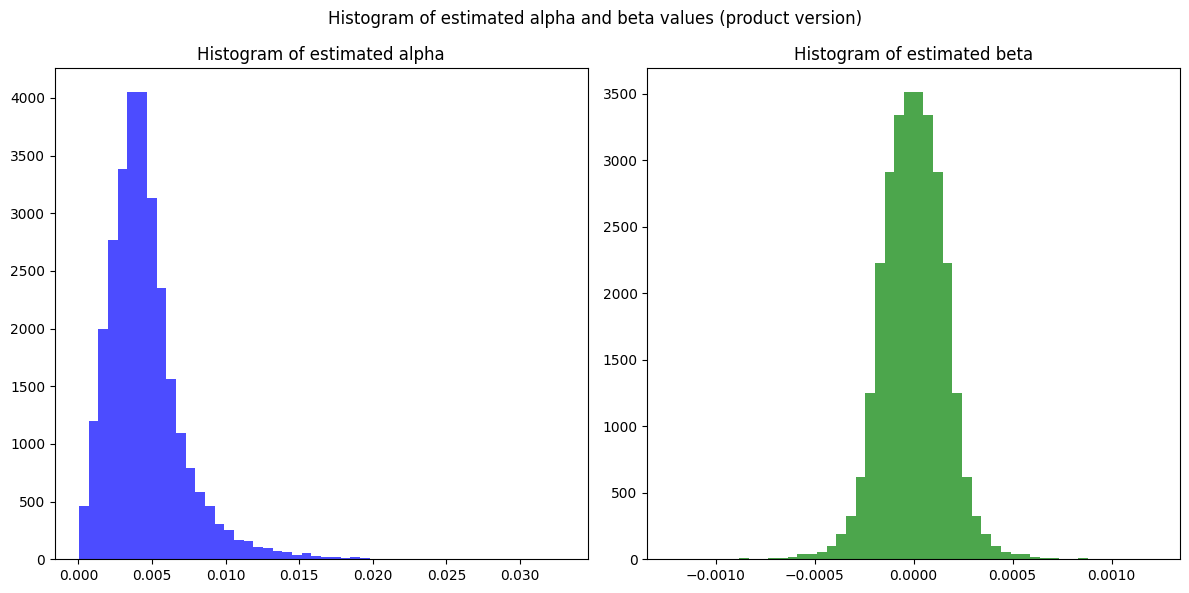

In [11]:
epsilon = find_espilon(W)*2
K = torch.exp(-W / epsilon)

# Recover the estimates
K_alpha = (K * K.T).sqrt()
K_beta = K / K_alpha

alpha_hat_prod = - epsilon * torch.log(K_alpha)
beta_hat_prod = - epsilon * torch.log(K_beta)

fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].hist(alpha_hat_prod[valid_edges_plt].cpu().numpy(), bins=50, color='blue', alpha=0.7)
axes[0].set_title("Histogram of estimated alpha")
axes[1].hist(beta_hat_prod[valid_edges_plt].cpu().numpy(), bins=50, color='green', alpha=0.7)
axes[1].set_title("Histogram of estimated beta")
plt.suptitle("Histogram of estimated alpha and beta values (product version)")
plt.tight_layout()

In [12]:
omega_hat = OmegaModel(latent_dim=2, hidden_dims=[8,8,8]).to(torch.double)
losses = learn_omega(X, beta_hat_prod, valid_edges, omega_hat, lr=1e-2, n_iter=500)
# losses = learn_omega(X, beta_hat_sum, valid_edges, omega_hat, lr=1e-2, n_iter=500)


Learning omega_hat: 100%|██████████| 500/500 [00:01<00:00, 305.38it/s, loss=4.61e-9]


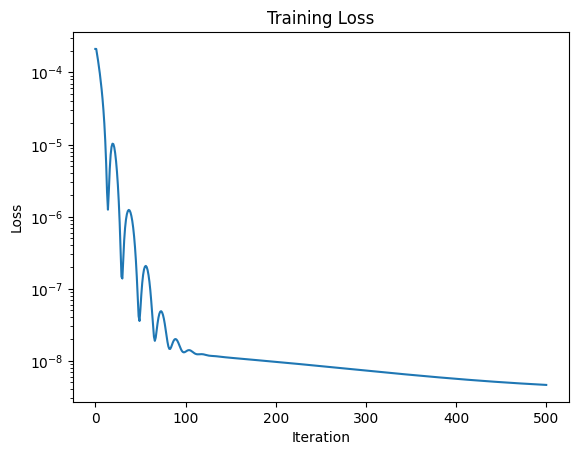

In [13]:
plt.plot(losses)
plt.yscale('log')
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

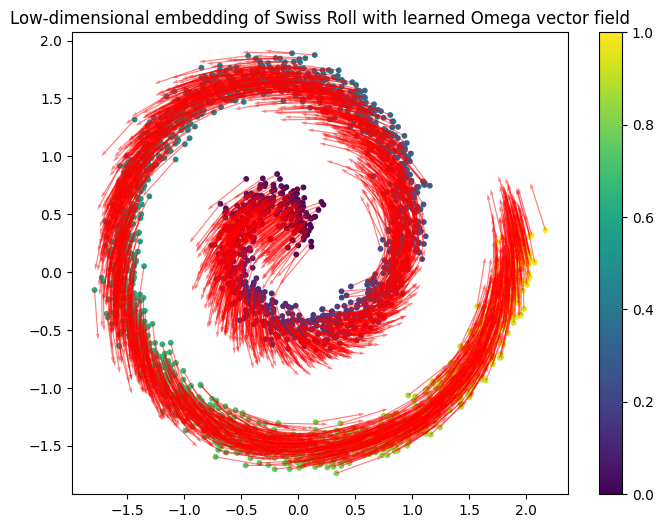

In [14]:
omega_low = omega_hat(X).detach()
omega_low = omega_low / torch.norm(omega_low, dim=1, keepdim=True)

fig,ax = plt.subplots(figsize=(8,6))
c=ax.scatter(X[:,0], X[:,1], c=t, cmap='viridis', s=10)
ax.quiver(X[:,0], X[:,1], omega_low[:,0], omega_low[:,1], color='red', alpha=0.5, scale=10,angles='xy')
ax.set_title("Low-dimensional embedding of Swiss Roll with learned Omega vector field")
fig.colorbar(c)
plt.show()

In [15]:
cometric_hat = CometricHat(latent_dim=2, hidden_dims=[8,8,8]).to(torch.double)
losses = learn_alpha(X, alpha_hat_prod, valid_edges, cometric_hat, lr=1e-2, n_iter=5000)

Learning alpha_hat: 100%|██████████| 5000/5000 [00:19<00:00, 251.82it/s, loss=2.59e-6]


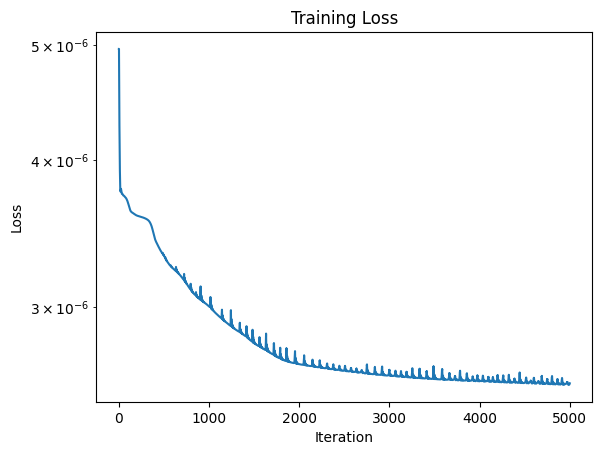

In [16]:
plt.plot(losses)
plt.yscale('log')
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 5510.10batch/s]


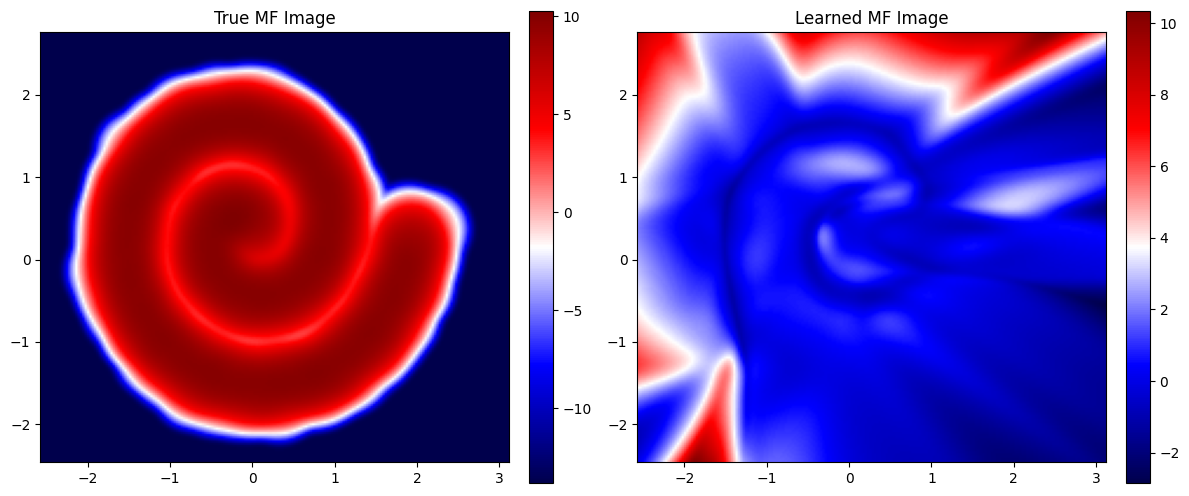

In [17]:
mf_hat = get_mf_image(cometric_hat, X, bounds)


fig, axes = plt.subplots(1,2, figsize=(12, 6))
im_true = axes[0].imshow(mf.cpu().numpy(), cmap="seismic", origin="lower", extent=bounds)
im_hat = axes[1].imshow(mf_hat.cpu().numpy(), cmap="seismic", origin="lower", extent=bounds)
axes[0].set_title("True MF Image")
axes[1].set_title("Learned MF Image")
fig.colorbar(im_true, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im_hat, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [18]:
#Pick a random points
idx = torch.randint(0, X.shape[0], (1,))
G_true= base_cometric.metric_tensor(X[idx])
G_hat = cometric_hat.metric_tensor(X[idx])
print(f"True metric tensor at point {idx.item()}: {G_true}")
print(f"Learned metric tensor at point {idx.item()}: {G_hat}")

# Pick a random edge
idx = torch.randint(0, valid_edges.shape[0], (1,))
edge = valid_edges[idx]
z_i = X[edge[:,0]]
z_j = X[edge[:,1]]
alpha_true_e = base_cometric.metric(z_i, (z_j - z_i))
alpha_hat_e = cometric_hat.metric(z_i, (z_j - z_i))
print(f"True alpha at edge {edge.squeeze()}: {alpha_true_e}")
print(f"Learned alpha at edge {edge.squeeze()}: {alpha_hat_e}")

True metric tensor at point 998: tensor([[0.0097, 0.0097]], dtype=torch.float64)
Learned metric tensor at point 998: tensor([[0.6923, 0.7355]], dtype=torch.float64, grad_fn=<SoftplusBackward0>)
True alpha at edge tensor([2341, 2353]): tensor([1.9737e-06], dtype=torch.float64)
Learned alpha at edge tensor([2341, 2353]): tensor([0.0003], dtype=torch.float64, grad_fn=<SumBackward1>)


# Swiss roll 

In [19]:
class SwissRollOmega(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, points):
        t_hat = torch.sqrt(points[:, 0] ** 2 + points[:, 2] ** 2)
        dx = torch.cos(t_hat) - t_hat * torch.sin(t_hat)
        dy = torch.ones_like(t_hat)
        dz = torch.sin(t_hat) + t_hat * torch.cos(t_hat)
        omega = torch.stack((dx, dy, dz), dim=1)
        omega = omega / torch.norm(omega, dim=1, keepdim=True)
        return omega

class SwissRollOmegaRandom(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, points):
        omega = torch.randn(points.shape[0], 3, device=points.device)
        omega = omega / torch.norm(omega, dim=1, keepdim=True)
        return omega




In [20]:
z, t = make_swiss_roll(n_samples=2000, noise=0.1)
z = torch.tensor(z)


base_cometric = CentroidsCometric(z, IdentityCoMetric()(z), K=-1, temperature_scale=0.5)

omega_true = SwissRollOmega()
randers = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=0.9
)

omega_z = omega_true(z)

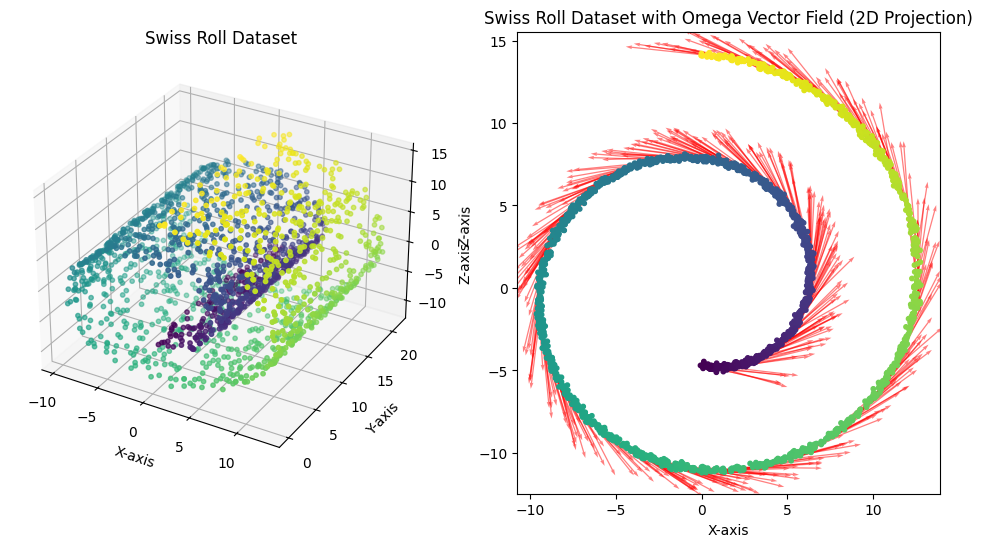

In [21]:
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(z[:,0], z[:,1], z[:,2], c=t, cmap='viridis', s=10)
ax1.set_title("Swiss Roll Dataset")
ax1.set_xlabel("X-axis")
ax1.set_ylabel("Y-axis")
ax1.set_zlabel("Z-axis")
ax2 = fig.add_subplot(122,)
ax2.quiver(z[::5,0], z[::5,2],omega_z[::5,0], omega_z[::5,2], color='red', alpha=0.5, scale=5,angles='xy')
ax2.scatter(z[:,0], z[:,2], c=t, cmap='viridis', s=10)
ax2.set_title("Swiss Roll Dataset with Omega Vector Field (2D Projection)")
ax2.set_xlabel("X-axis")
ax2.set_ylabel("Z-axis")
plt.show()

In [22]:
solver_r = SolverGraph(cometric=base_cometric,
                       data=z,
                       n_neighbors=6,
                       )
solver_f = SolverGraphFinsler(finsler_metric=randers,
                            data=z,
                            n_neighbors=6,
                            )

Initialize Graph: 100%|██████████| 32/32 [00:15<00:00,  2.13batch/s]


Computing predecessors...
Done.


Initialize Graph: 100%|██████████| 32/32 [00:15<00:00,  2.01batch/s]


Computing predecessors...
Done.


In [23]:
W = solver_f.W
valid_edges_plt = W > 0
valid_edges = valid_edges_plt.nonzero(as_tuple=False)

alpha_true = solver_r.W
edges = solver_f.W.nonzero(as_tuple=False)
dx = z[edges[:, 1]] - z[edges[:, 0]]
beta_true = torch.einsum('bi,bi->b', omega_true(z[edges[:, 0]]), dx)
beta_true = randers.beta * beta_true

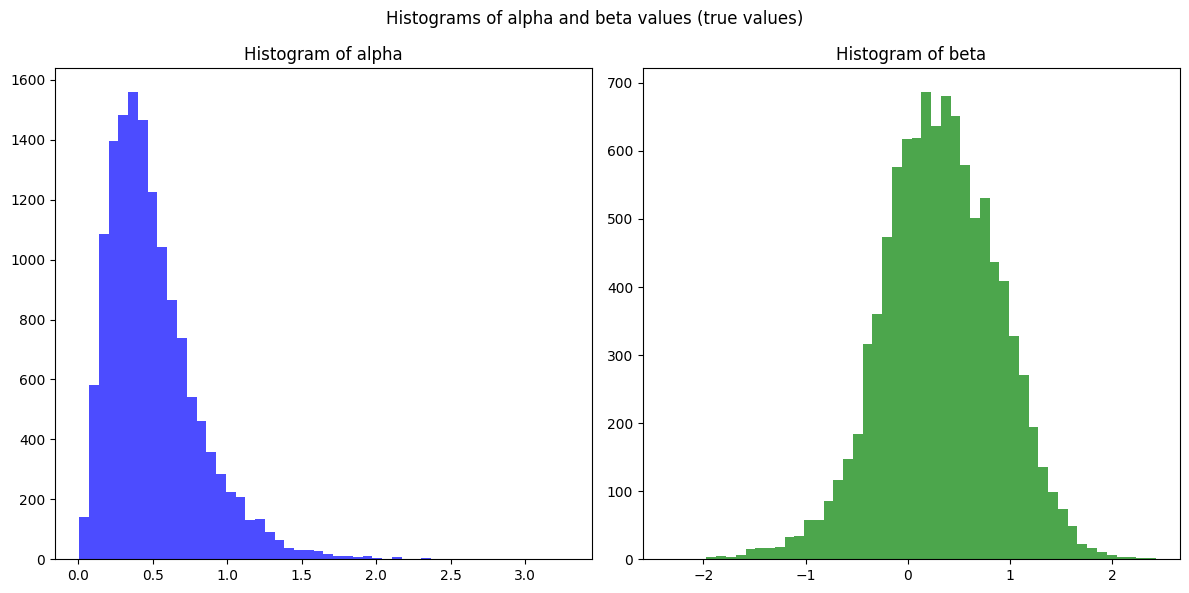

In [24]:
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].hist(alpha_true[alpha_true>0].cpu().numpy(), bins=50, color='blue', alpha=0.7)
axes[0].set_title("Histogram of alpha")
axes[1].hist(beta_true.cpu().numpy(), bins=50, color='green', alpha=0.7)
axes[1].set_title("Histogram of beta")
plt.suptitle("Histograms of alpha and beta values (true values)")
plt.tight_layout()

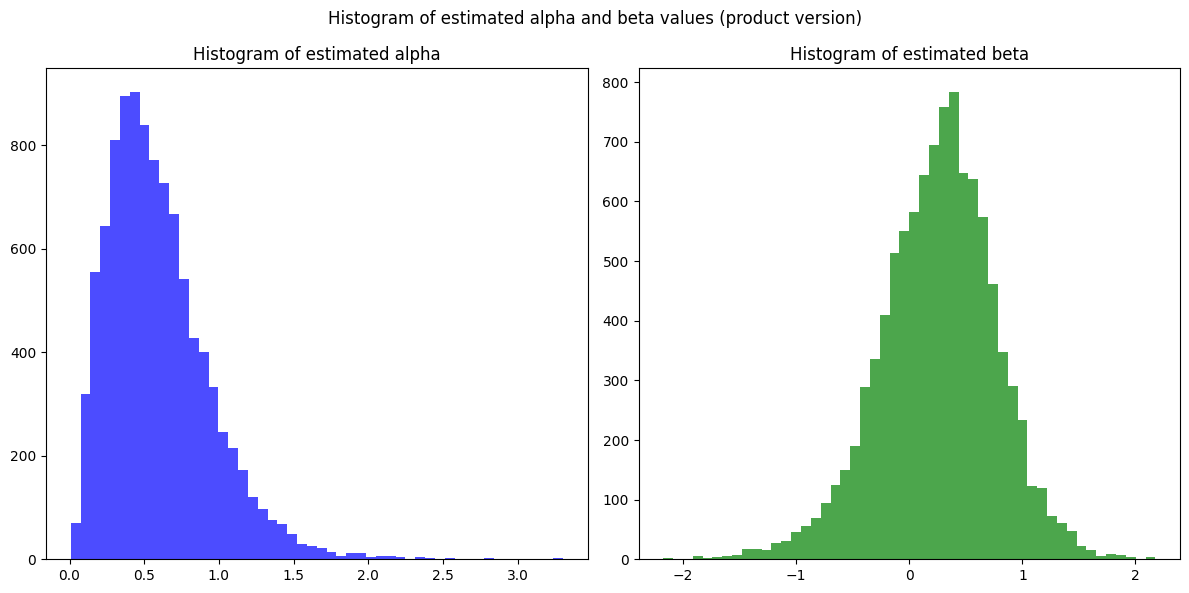

In [25]:
epsilon = find_espilon(W)*2
K = torch.exp(-W / epsilon)

# Recover the estimates
K_alpha = (K * K.T).sqrt()
K_beta = K / K_alpha

alpha_hat_prod = - epsilon * torch.log(K_alpha)
beta_hat_prod = - epsilon * torch.log(K_beta)

fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].hist(alpha_hat_prod[valid_edges_plt].cpu().numpy(), bins=50, color='blue', alpha=0.7)
axes[0].set_title("Histogram of estimated alpha")
axes[1].hist(beta_hat_prod[valid_edges_plt].cpu().numpy(), bins=50, color='green', alpha=0.7)
axes[1].set_title("Histogram of estimated beta")
plt.suptitle("Histogram of estimated alpha and beta values (product version)")
plt.tight_layout()

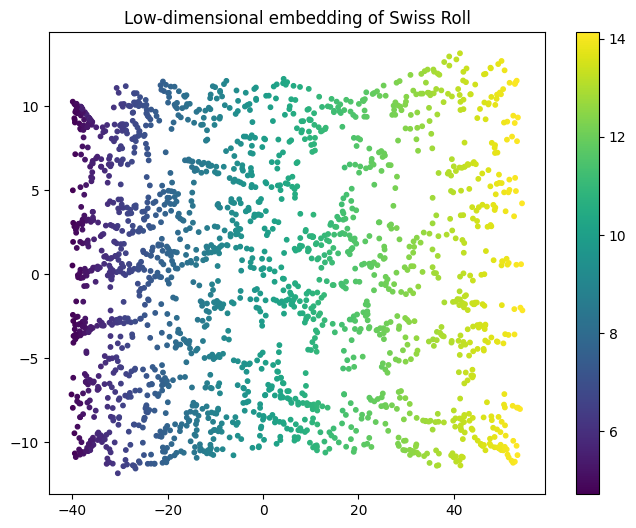

In [26]:
# Embedding the data using various dimensionality reduction techniques
from sklearn.decomposition import KernelPCA,PCA
from sklearn.manifold import SpectralEmbedding
from sklearn.manifold import MDS,TSNE,Isomap

model = SpectralEmbedding(n_components=2, random_state=1312)
# model = PCA(n_components=2,random_state=1312)
# model = KernelPCA(n_components=2, random_state=1312)
model = MDS(n_components=2,random_state=1312)
# model = TSNE(n_components=2,random_state=1312,init="random")
model = Isomap(n_components=2, n_neighbors=8)

z_low = model.fit_transform(z)
z_low = torch.tensor(z_low).to(torch.double)

fig,ax = plt.subplots(figsize=(8,6))
c = ax.scatter(z_low[:,0], z_low[:,1], c=t, cmap='viridis', s=10)
ax.set_title("Low-dimensional embedding of Swiss Roll")
fig.colorbar(c)
plt.show()

In [27]:
omega_hat = OmegaModel(latent_dim=2, hidden_dims=[8,8,8]).to(torch.double)
losses = learn_omega(z_low, beta_hat_prod, valid_edges, omega_hat, lr=1e-2, n_iter=1000)


Learning omega_hat: 100%|██████████| 1000/1000 [00:02<00:00, 334.30it/s, loss=0.0335]


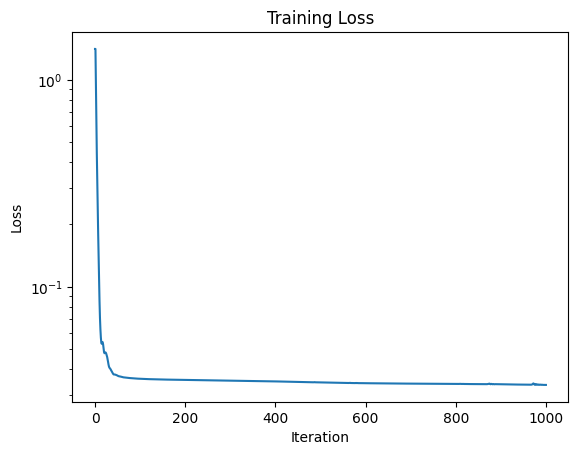

In [28]:
plt.plot(losses)
plt.yscale('log')
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

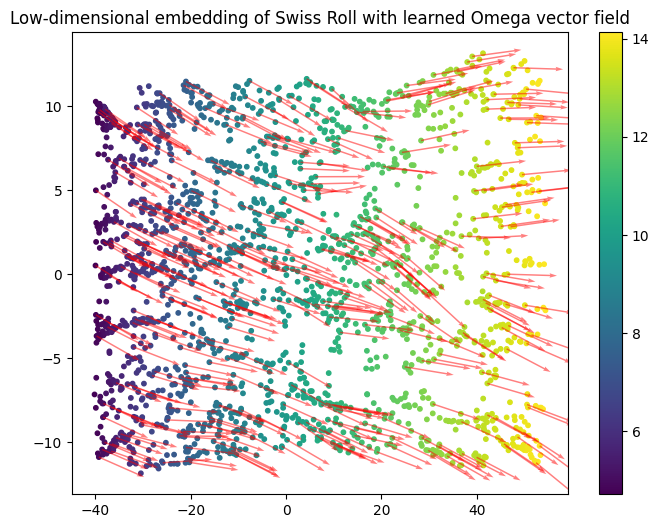

In [29]:
omega_low = omega_hat(z_low).detach()
omega_low = omega_low / torch.norm(omega_low, dim=1, keepdim=True)

fig,ax = plt.subplots(figsize=(8,6))
c=ax.scatter(z_low[:,0], z_low[:,1], c=t, cmap='viridis', s=10)
ax.quiver(z_low[::5,0], z_low[::5,1], omega_low[::5,0], omega_low[::5,1], color='red', alpha=0.5, scale=10,angles='xy')
ax.set_title("Low-dimensional embedding of Swiss Roll with learned Omega vector field")
fig.colorbar(c)
plt.show()

In [30]:
cometric_hat = CometricHat(latent_dim=2, hidden_dims=[8,8,8]).to(torch.double)
losses = learn_alpha(z_low, alpha_hat_prod, valid_edges, cometric_hat, lr=1e-2, n_iter=500)

Learning alpha_hat: 100%|██████████| 500/500 [00:01<00:00, 311.80it/s, loss=0.0933]


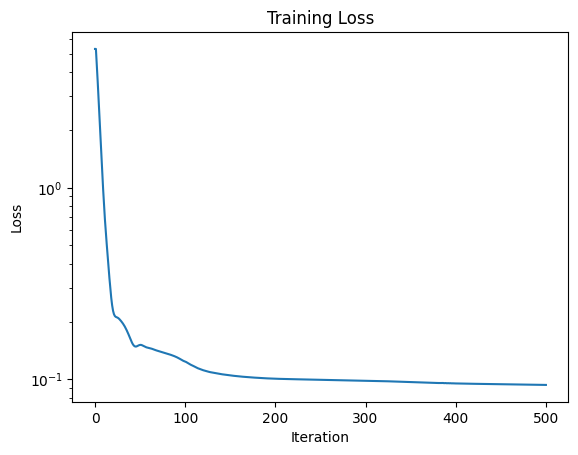

In [31]:
plt.plot(losses)
plt.yscale('log')
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 6186.29batch/s]


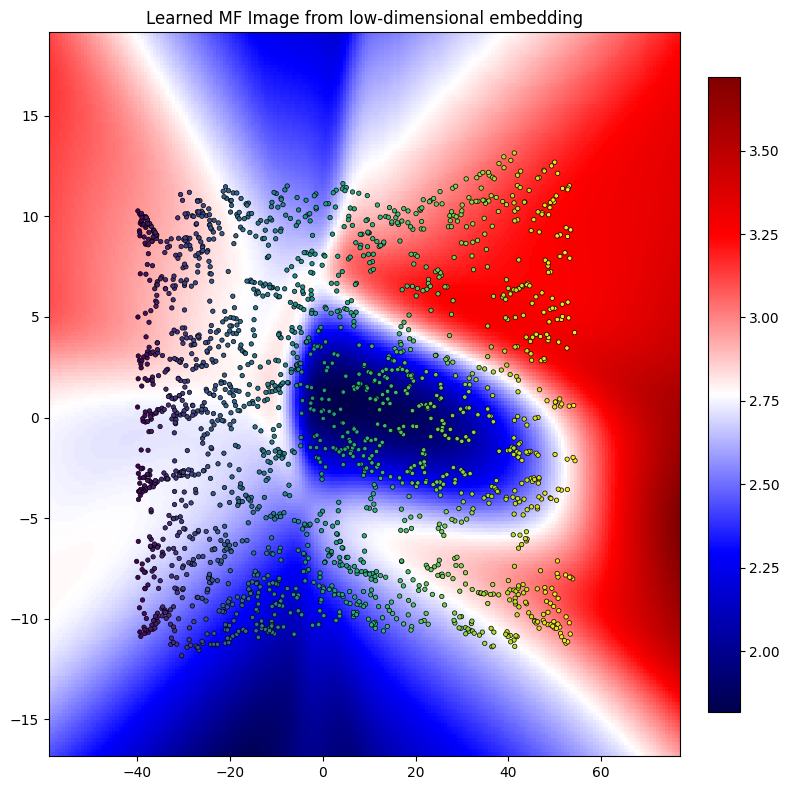

In [32]:
mf_hat = get_mf_image(cometric_hat, z_low, get_bounds(z_low, margin=0.0))

fig,ax = plt.subplots(figsize=(8,8))
im = ax.imshow(mf_hat.cpu().numpy(), cmap="seismic", origin="lower", extent=get_bounds(z_low, margin=0.2))
ax.scatter(z_low[:,0].cpu(), z_low[:,1].cpu(), c=t, cmap='viridis', s=10, edgecolor='k', linewidth=0.5)
ax.set_title("Learned MF Image from low-dimensional embedding")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_aspect('auto')
plt.tight_layout()
plt.show()